# DBSCAN

## You want to map out the Crowd. You dont look for the exact geographic center of the park. You just look for where people are standing shoulder to shoulder

## If a person can reach out their arms and touch at least 4 people , They are standing in a crowd. if the crowd links hands with another crowd, the massive chain becoes one gaint Flash Mob.

## This is DBSCAN . It groups data points together that are packed closely together, and it completely ignores the empty space.

## Two Master Parameters:

### Epsilon: 
#### "The Arm's Length"
#### -What is the maximum distance a dot can reach out to find a neighbor?
#### e.g. E:2 meters





### MinPts:
#### "The Squad Size"
#### - How many  neighbors must be inside that arm's length to officially be considered a dense crowd?
####  e.g MinPts = 4

## The Anatomy of the Crowd:

### 1. The core Points:
#### A dot that has at least MinPts neighbors within its E radius. It is deep inside the thickest part od the crowd.

### 2. The Border Point:
#### A dot that does not have enough neighbors to be a Core But it is standing right next to a Core points. It is on the g=fringe of the crowd

### 3. Noise/Outlier:
#### A dot that has no friends,. It dosent have enough neighbors and it is not standing next to a  Core . I is abandoned

In [3]:
import pandas as pd

In [2]:
x = [1,2,2,8,8,25,7,1,8,7]
y = [2,2,3,7,8,80,7,3,9,8]

In [4]:
df = pd.DataFrame({'x':x,'y':y})

In [5]:
df

,x,y
0,1,2
1,2,2
2,2,3
3,8,7
4,8,8
5,25,80
6,7,7
7,1,3
8,8,9
9,7,8


In [6]:
from sklearn.cluster import DBSCAN

In [7]:
dscan = DBSCAN(eps=1.5,min_samples=4)

In [9]:
dscan.fit([df["x"]],df["y"])

,eps,1.5
,min_samples,4
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [10]:
df["Clusters"]=dscan.fit_predict(df)

In [11]:
dscan.labels_

array([ 0,  0,  0,  1,  1, -1,  1,  0,  1,  1])

In [12]:
df

,x,y,Clusters
0,1,2,0
1,2,2,0
2,2,3,0
3,8,7,1
4,8,8,1
5,25,80,-1
6,7,7,1
7,1,3,0
8,8,9,1
9,7,8,1


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='x', ylabel='y'>

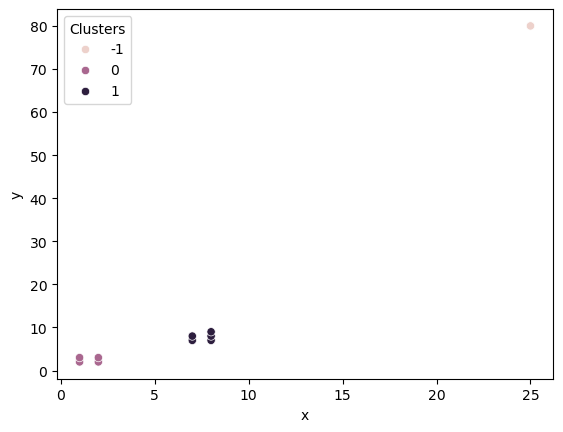

In [17]:
sns.scatterplot(data=df,x="x",y="y",hue="Clusters")